# Part F — Extended: Build the Weekly Risk Dashboard


---


Build a Python script (or Jupyter notebook section) that generates a weekly risk summary CSV from the scored loan data. The summary must include:

* Total applications processed, broken down by
risk_tier (High / Medium / Low).
*	Default rate by branch (% of Defaulted loans out of all closed loans per branch).
*	Average credit_score and average loan_amount by risk_tier.
*	Top 3 loan purposes by high-risk application count.

Save the output as finsight_weekly_risk_summary.csv. In a markdown cell, write 3 sentences summarising the week's findings in the language of the CFO's monthly risk report.


In [2]:
import pandas as pd
from google.colab import drive
from IPython.display import display, HTML
import os
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

# Load scored applications
scored = pd.read_csv('/content/drive/MyDrive/FDE Projects/FinSight/finsight_high_risk_with_alerts.csv')
full = pd.read_csv('/content/drive/MyDrive/FDE Projects/FinSight/finsight_synthetic_2k_final.csv')

# Merge risk_tier and default_probability into full dataset
full = full.merge(
    scored[['loan_id','default_probability','risk_tier']],
    on='loan_id', how='left'
)
full['risk_tier'] = full['risk_tier'].fillna('Low')

# 1 — Applications by risk tier
tier_counts = full['risk_tier'].value_counts().reset_index()
tier_counts.columns = ['risk_tier', 'application_count']
tier_counts['pct_of_total'] = (tier_counts['application_count'] / len(full) * 100).round(1)

print("=== APPLICATIONS BY RISK TIER ===")
print(tier_counts)

# 2 — Default rate by branch
branch_default = full.groupby('branch').agg(
    total=('loan_id','count'),
    defaults=('default_flag','sum')
).reset_index()
branch_default['default_rate_pct'] = (branch_default['defaults'] / branch_default['total'] * 100).round(1)
branch_default = branch_default.sort_values('default_rate_pct', ascending=False)

print("\n=== DEFAULT RATE BY BRANCH ===")
print(branch_default)

# 3 — Avg credit score and loan amount by risk tier
tier_stats = full.groupby('risk_tier').agg(
    avg_credit_score=('credit_score','mean'),
    avg_loan_amount=('loan_amount','mean')
).round(0).reset_index()

print("\n=== AVG CREDIT SCORE + LOAN AMOUNT BY RISK TIER ===")
print(tier_stats)

# 4 — Top 3 loan purposes by high risk count
top_purposes = full[full['risk_tier']=='High']['loan_purpose'].value_counts().head(3).reset_index()
top_purposes.columns = ['loan_purpose', 'high_risk_count']

print("\n=== TOP 3 LOAN PURPOSES BY HIGH RISK COUNT ===")
print(top_purposes)

=== APPLICATIONS BY RISK TIER ===
  risk_tier  application_count  pct_of_total
0       Low               1890          94.5
1      High                110           5.5

=== DEFAULT RATE BY BRANCH ===
      branch  total  defaults  default_rate_pct
3  Hyderabad    259        81              31.3
5     Mumbai    284        85              29.9
4    Kolkata    304        90              29.6
6       Pune    279        78              28.0
0  Bangalore    281        78              27.8
2      Delhi    301        81              26.9
1    Chennai    292        61              20.9

=== AVG CREDIT SCORE + LOAN AMOUNT BY RISK TIER ===
  risk_tier  avg_credit_score  avg_loan_amount
0      High             557.0         577317.0
1       Low             664.0         455678.0

=== TOP 3 LOAN PURPOSES BY HIGH RISK COUNT ===
  loan_purpose  high_risk_count
0         Home               24
1    Education               24
2      Vehicle               22


In [4]:
# Build summary CSV
summary_rows = []

# Section 1 — Tier distribution
for _, row in tier_counts.iterrows():
    summary_rows.append({
        'metric': 'Applications by Risk Tier',
        'dimension': row['risk_tier'],
        'value': row['application_count'],
        'pct': row['pct_of_total']
    })

# Section 2 — Default rate by branch
for _, row in branch_default.iterrows():
    summary_rows.append({
        'metric': 'Default Rate by Branch',
        'dimension': row['branch'],
        'value': row['defaults'],
        'pct': row['default_rate_pct']
    })

# Section 3 — Avg stats by tier
for _, row in tier_stats.iterrows():
    summary_rows.append({
        'metric': 'Avg Credit Score by Tier',
        'dimension': row['risk_tier'],
        'value': row['avg_credit_score'],
        'pct': None
    })
    summary_rows.append({
        'metric': 'Avg Loan Amount by Tier',
        'dimension': row['risk_tier'],
        'value': row['avg_loan_amount'],
        'pct': None
    })

# Section 4 — Top purposes
for _, row in top_purposes.iterrows():
    summary_rows.append({
        'metric': 'Top Loan Purposes (High Risk)',
        'dimension': row['loan_purpose'],
        'value': row['high_risk_count'],
        'pct': None
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv('/content/drive/MyDrive/FDE Projects/FinSight/finsight_weekly_risk_summary.csv', index=False)
print("Summary CSV saved")
print(summary_df)

Summary CSV saved
                           metric  dimension     value   pct
0       Applications by Risk Tier        Low    1890.0  94.5
1       Applications by Risk Tier       High     110.0   5.5
2          Default Rate by Branch  Hyderabad      81.0  31.3
3          Default Rate by Branch     Mumbai      85.0  29.9
4          Default Rate by Branch    Kolkata      90.0  29.6
5          Default Rate by Branch       Pune      78.0  28.0
6          Default Rate by Branch  Bangalore      78.0  27.8
7          Default Rate by Branch      Delhi      81.0  26.9
8          Default Rate by Branch    Chennai      61.0  20.9
9        Avg Credit Score by Tier       High     557.0   NaN
10        Avg Loan Amount by Tier       High  577317.0   NaN
11       Avg Credit Score by Tier        Low     664.0   NaN
12        Avg Loan Amount by Tier        Low  455678.0   NaN
13  Top Loan Purposes (High Risk)       Home      24.0   NaN
14  Top Loan Purposes (High Risk)  Education      24.0   NaN
15  To

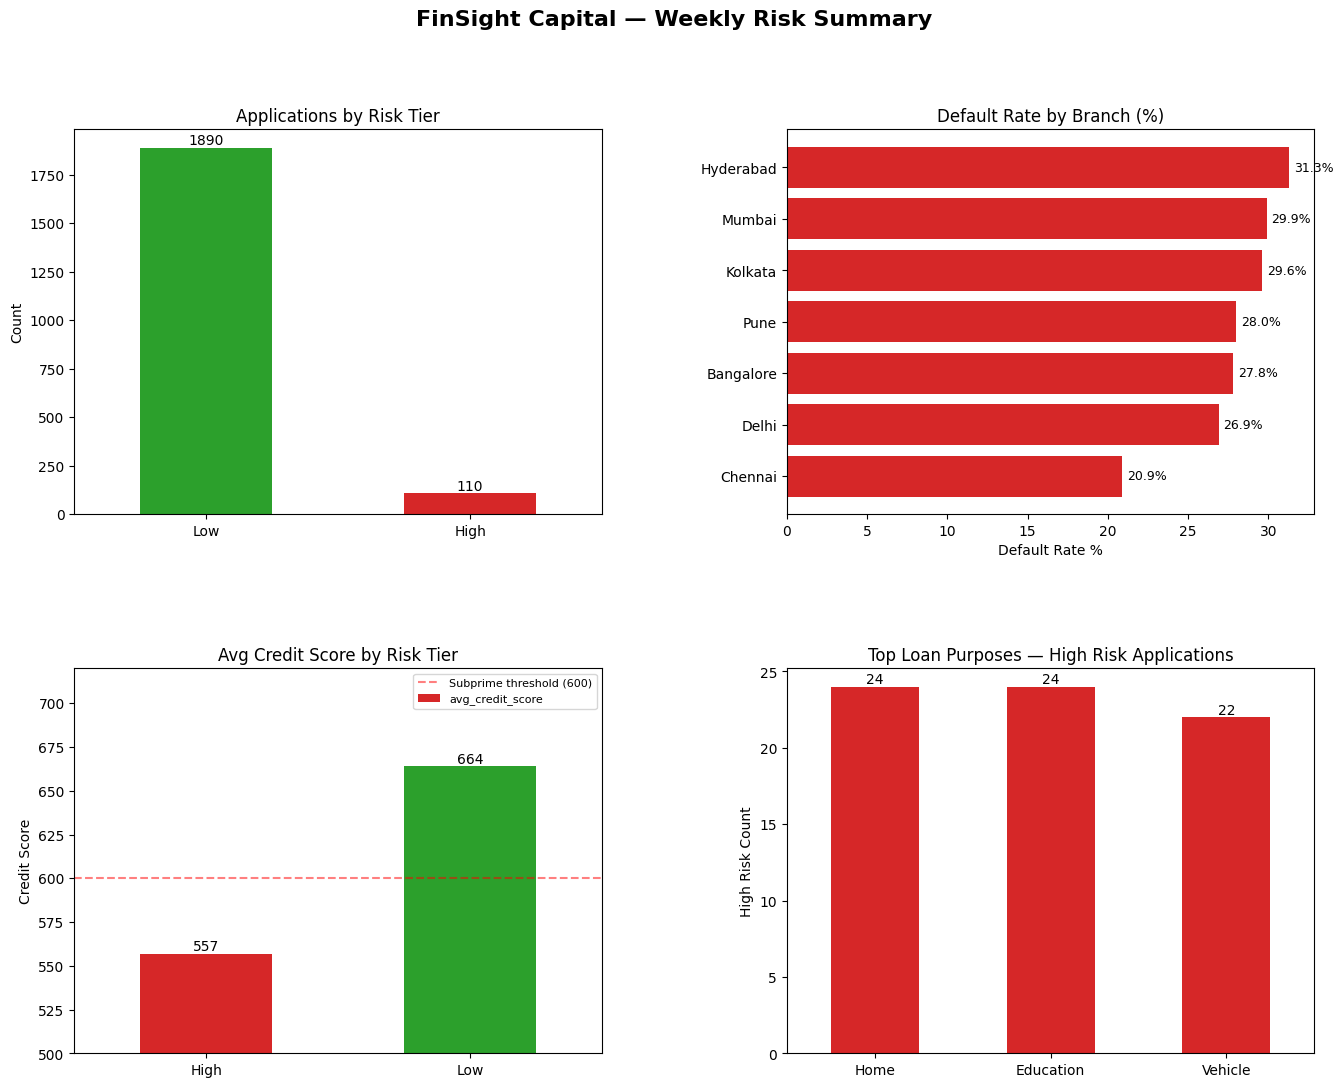

Chart saved to Drive


In [5]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 12))
fig.suptitle('FinSight Capital — Weekly Risk Summary', fontsize=16, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# 1 — Risk Tier Distribution
ax1 = fig.add_subplot(gs[0, 0])
tier_counts_plot = tier_counts.set_index('risk_tier')['application_count']
colors = {'High': '#d62728', 'Medium': '#ff7f0e', 'Low': '#2ca02c'}
tier_counts_plot.plot(kind='bar', ax=ax1,
    color=[colors.get(x, '#1f77b4') for x in tier_counts_plot.index])
ax1.set_title('Applications by Risk Tier')
ax1.set_xlabel('')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=0)
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10)

# 2 — Default Rate by Branch
ax2 = fig.add_subplot(gs[0, 1])
branch_default_sorted = branch_default.sort_values('default_rate_pct')
ax2.barh(branch_default_sorted['branch'],
         branch_default_sorted['default_rate_pct'],
         color='#d62728')
ax2.set_title('Default Rate by Branch (%)')
ax2.set_xlabel('Default Rate %')
for i, v in enumerate(branch_default_sorted['default_rate_pct']):
    ax2.text(v + 0.3, i, f'{v}%', va='center', fontsize=9)

# 3 — Avg Credit Score by Risk Tier
ax3 = fig.add_subplot(gs[1, 0])
tier_stats_plot = tier_stats.set_index('risk_tier')['avg_credit_score']
tier_stats_plot.plot(kind='bar', ax=ax3,
    color=[colors.get(x, '#1f77b4') for x in tier_stats_plot.index])
ax3.set_title('Avg Credit Score by Risk Tier')
ax3.set_xlabel('')
ax3.set_ylabel('Credit Score')
ax3.set_ylim(500, 720)
ax3.tick_params(axis='x', rotation=0)
ax3.axhline(y=600, color='red', linestyle='--', alpha=0.5, label='Subprime threshold (600)')
ax3.legend(fontsize=8)
for p in ax3.patches:
    ax3.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10)

# 4 — Top 3 Loan Purposes by High Risk
ax4 = fig.add_subplot(gs[1, 1])
top_purposes.plot(kind='bar', x='loan_purpose', y='high_risk_count',
                  ax=ax4, color='#d62728', legend=False)
ax4.set_title('Top Loan Purposes — High Risk Applications')
ax4.set_xlabel('')
ax4.set_ylabel('High Risk Count')
ax4.tick_params(axis='x', rotation=0)
for p in ax4.patches:
    ax4.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.savefig('/content/drive/MyDrive/FDE Projects/FinSight/finsight_weekly_risk_chart.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to Drive")